In [11]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
df = pd.read_csv("final_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.head()

,TransactionID,Date,Time,Company,LocationID,City,FuelType,Quantity_Liters,Price_per_Litre,Total_Amount,PaymentMethod,VehicleType,LoyaltyCardUsed,PumpNumber,EmployeeID
0,TXN001,2024-01-03,05:44:00,HP,delhi-pump-04,delhi,petrol,26.30,94.46,2484.30,UPI,car,No,3,E-DEL-4
1,TXN002,2025-02-04,21:08:00,IOCL,pune-pump-01,pune,diesel,42.89,87.57,3755.88,Card,car,Yes,5,E-PUN-3
2,TXN003,2024-08-25,06:39:00,BPCL,mumbai-pump-02,mumbai,diesel,10.42,88.11,918.11,Card,bike,Yes,1,E-MUM-2
3,TXN004,2025-01-05,15:20:00,IOCL,bangalore-pump-07,bangalore,petrol,14.49,95.10,1378.00,Cash,bike,No,2,E-BAN-1
4,TXN005,2025-04-09,19:52:00,HP,mumbai-pump-02,mumbai,diesel,39.37,87.21,3433.46,Cash,car,No,5,E-MUM-5


In [15]:
# Aggregate daily sales
daily_sales = df.groupby('Date')['Total_Amount'].sum().reset_index()
daily_sales.head()

,Date,Total_Amount
0,2024-01-01,4061.05
1,2024-01-02,4326.18
2,2024-01-03,10197.08
3,2024-01-04,5632.04
4,2024-01-05,5354.86


In [16]:
# Cell 3: Prepare Training Data (Jan 1–30 for 2024 & 2025)
train_data = daily_sales[
    ((daily_sales['Date'].dt.year.isin([2024, 2025])) &
     (daily_sales['Date'].dt.month == 1) &
     (daily_sales['Date'].dt.day <= 30))
].copy()

train_data['Day'] = train_data['Date'].dt.day
train_data['Year'] = train_data['Date'].dt.year
train_data['DayOfWeek'] = train_data['Date'].dt.dayofweek

# Show training data
train_data.head(10)

,Date,Total_Amount,Day,Year,DayOfWeek
0,2024-01-01,4061.05,1,2024,0
1,2024-01-02,4326.18,2,2024,1
2,2024-01-03,10197.08,3,2024,2
3,2024-01-04,5632.04,4,2024,3
4,2024-01-05,5354.86,5,2024,4
5,2024-01-06,6079.64,6,2024,5
6,2024-01-07,6695.99,7,2024,6
7,2024-01-08,4408.34,8,2024,0
8,2024-01-09,1663.14,9,2024,1
9,2024-01-10,8396.42,10,2024,2


In [17]:
# Cell 4: Train Model
X_train = train_data[['Day','Year','DayOfWeek']]
y_train = train_data['Total_Amount']

reg_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
reg_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [20]:
# Cell 5: Testing Data (Jan 2025)
test_data = train_data[train_data['Year']==2025]
X_test = test_data[['Day','Year','DayOfWeek']]
y_test = test_data['Total_Amount']

y_pred = reg_model.predict(X_test)

# Show actual vs predicted
results = pd.DataFrame({
    'Date': test_data['Date'],
    'Actual_Total_Amount': y_test,
    'Predicted_Total_Amount': y_pred
})
results.head(10)

,Date,Actual_Total_Amount,Predicted_Total_Amount
276,2025-01-01,5859.80,5884.548340
277,2025-01-03,977.82,1137.834473
278,2025-01-04,2309.28,2423.708008
279,2025-01-05,4165.08,4016.615479
280,2025-01-07,5311.07,5282.525391
281,2025-01-09,2309.65,2253.817627
282,2025-01-10,447.00,683.587830
283,2025-01-11,3178.07,3081.795654
284,2025-01-15,12071.56,11574.395508
285,2025-01-17,1051.20,1118.672119


In [21]:
# Cell 6: Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("----- Forecasting Evaluation (on Jan 2025) -----")
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2:", round(r2,4))

----- Forecasting Evaluation (on Jan 2025) -----
MAE: 145.75
RMSE: 205.33
R2: 0.9935


In [22]:
# Cell 7: Forecast Jan 1–30, 2026
future_dates = pd.date_range('2026-01-01','2026-01-30')
future_df = pd.DataFrame({'Date': future_dates})
future_df['Day'] = future_df['Date'].dt.day
future_df['Year'] = future_df['Date'].dt.year
future_df['DayOfWeek'] = future_df['Date'].dt.dayofweek

future_df['Predicted_Total_Amount'] = reg_model.predict(future_df[['Day','Year','DayOfWeek']])
future_df.head(10)

,Date,Day,Year,DayOfWeek,Predicted_Total_Amount
0,2026-01-01,1,2026,3,3702.545166
1,2026-01-02,2,2026,4,1076.469482
2,2026-01-03,3,2026,5,2427.012451
3,2026-01-04,4,2026,6,3372.627686
4,2026-01-05,5,2026,0,4408.020020
5,2026-01-06,6,2026,1,5432.648438
6,2026-01-07,7,2026,2,7415.534180
7,2026-01-08,8,2026,3,3267.006592
8,2026-01-09,9,2026,4,451.510345
9,2026-01-10,10,2026,5,1844.024292


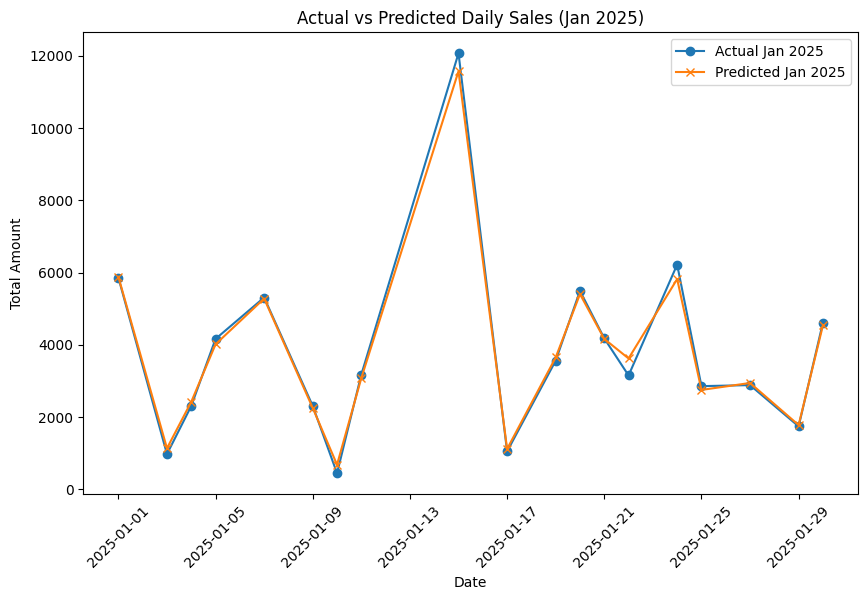

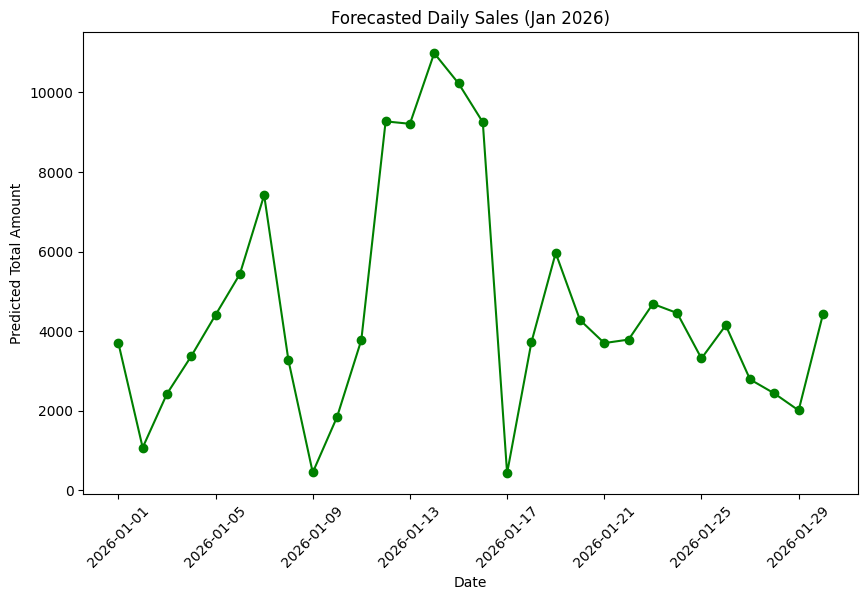

In [26]:
# Cell 8: Visualizations

# Actual vs Predicted (Jan 2025)
plt.figure(figsize=(10,6))
plt.plot(results['Date'], results['Actual_Total_Amount'], label="Actual Jan 2025", marker='o')
plt.plot(results['Date'], results['Predicted_Total_Amount'], label="Predicted Jan 2025", marker='x')
plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.title("Actual vs Predicted Daily Sales (Jan 2025)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Forecast Jan 2026
plt.figure(figsize=(10,6))
plt.plot(future_df['Date'], future_df['Predicted_Total_Amount'], marker='o', color='green')
plt.xlabel("Date")
plt.ylabel("Predicted Total Amount")
plt.title("Forecasted Daily Sales (Jan 2026)")
plt.xticks(rotation=45)
plt.show()

In [27]:
# Save actual vs predicted Jan 2025
results.to_csv("jan2025_actual_vs_predicted.csv", index=False)

# Save forecast Jan 2026
future_df.to_csv("forecast_jan2026.csv", index=False)

# Save training data (Jan 2024 & Jan 2025 actuals)
train_data.to_csv("jan2024_2025_actuals.csv", index=False)
